In [3]:
# tune regularization for multinomial logistic regression
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot

In [6]:
# get the dataset
def get_dataset():
 X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=1, n_classes=3)
 return X, y
 

In [97]:
# get a list of models to evaluate
def get_models():
 models = dict()
 for p in [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0]:
 # create name for model
  key = '%.4f' % p 
 # turn off penalty in some cases
  if p == 0.0:
 # no penalty in this case
    models[key] = LogisticRegression(multi_class='multinomial', solver='lbfgs')
  else:
    models[key] = LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty='l2', C=p)
 return models

In [77]:
# evaluate a give model using cross-validation
def evaluate_model(model, X, y):
 # define the evaluation procedure
 cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
 # evaluate the model
 scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
 return scores

In [65]:
# define dataset
X, y = get_dataset()


In [45]:
X

array([[  0.04339387,   2.75542632,  -3.79522705, ...,   2.50964286,
          2.18839505,  -2.31211692],
       [  1.58921003,   1.12666534,   0.66025949, ...,   5.29131489,
         -2.5934611 ,  -1.20527638],
       [ -0.85608532,   5.72305194,   1.21274572, ...,  -0.22724338,
         -2.68983808,   5.69506287],
       ...,
       [ -1.44794472,   1.42911238,  -0.2695061 , ..., -15.1699947 ,
         -1.14825019,  -1.91237285],
       [ -2.2462327 ,   0.73543753,   1.80454067, ...,   6.35671557,
         -1.96682962,   1.15566463],
       [ -4.62809731,  -1.78610583,   2.00023483, ...,  -9.30639391,
          0.91916085,  -3.45099051]])

In [101]:
# get the models to evaluate
models = get_models()
models

{'0.0000': LogisticRegression(multi_class='multinomial'),
 '0.0001': LogisticRegression(C=0.0001, multi_class='multinomial'),
 '0.0010': LogisticRegression(C=0.001, multi_class='multinomial'),
 '0.0100': LogisticRegression(C=0.01, multi_class='multinomial'),
 '0.1000': LogisticRegression(C=0.1, multi_class='multinomial'),
 '1.0000': LogisticRegression(multi_class='multinomial')}

>LogisticRegression(multi_class='multinomial') 0.0000 0.777 (0.037)


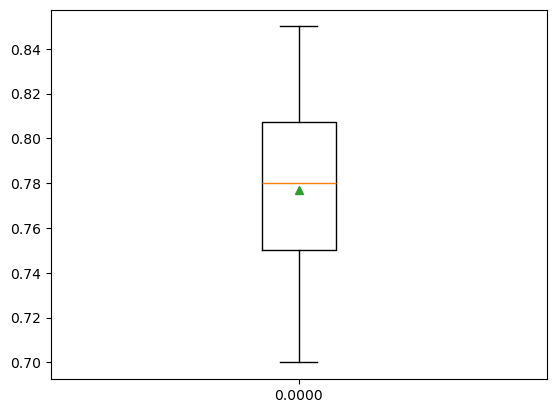

>LogisticRegression(C=0.0001, multi_class='multinomial') 0.0001 0.684 (0.049)


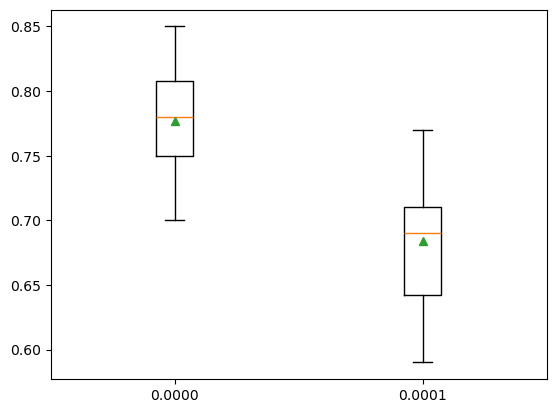

>LogisticRegression(C=0.001, multi_class='multinomial') 0.0010 0.762 (0.044)


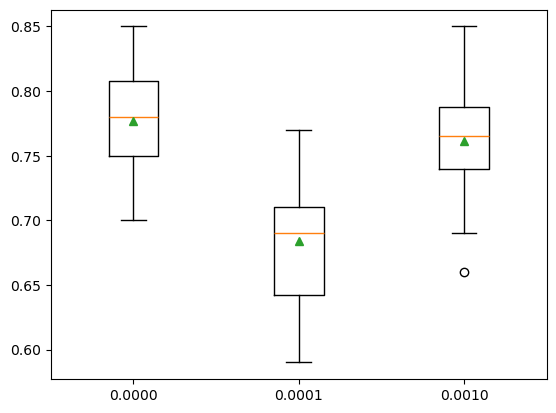

>LogisticRegression(C=0.01, multi_class='multinomial') 0.0100 0.775 (0.039)


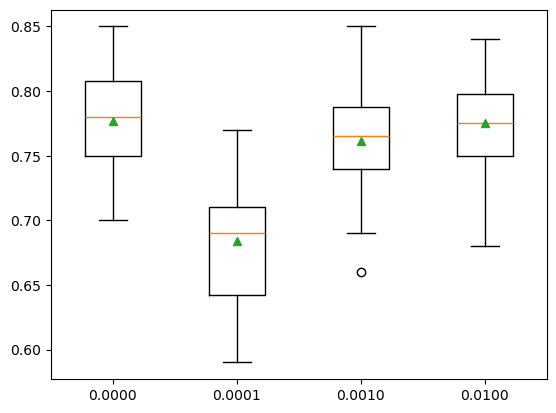

>LogisticRegression(C=0.1, multi_class='multinomial') 0.1000 0.774 (0.038)


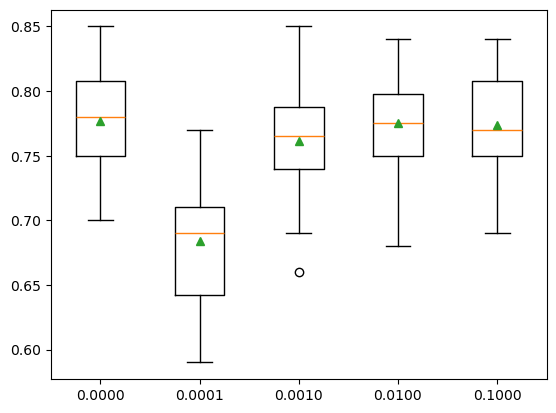

>LogisticRegression(multi_class='multinomial') 1.0000 0.777 (0.037)


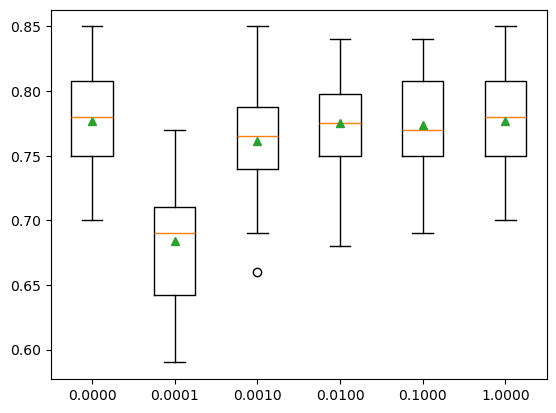

In [107]:
# evaluate the models and store results
results, names = list(), list()

for name, model in models.items():
 # evaluate the model and collect the scores
    scores = evaluate_model(model, X, y)
 # store the results
    results.append(scores)
    names.append(name)
 # summarize progress along the way
    print('>%s %s %.3f (%.3f)' % (model, name, mean(scores), std(scores)))
 # plot model performance for comparison
    pyplot.boxplot(results, labels=names, showmeans=True)
    pyplot.show()

- The larger penalty we use on this dataset (i.e. the smaller the C value), the worse the performance of the model.
- The weighting for the penalty is actually the inverse weighting, perhaps penalty = 1 – C.
From the documentation:
C : float, default=1.0
Inverse of regularization strength; must be a positive float. Like in support vector machines, smaller values specify stronger regularization.

- This means that values close to 1.0 indicate very little penalty and values close to zero indicate a strong penalty. A C value of 1.0 may indicate no penalty at all.
 C close to 1.0: Light penalty.
 C close to 0.0: Strong penalty.